# Оцінка моделей та Ансамблювання (Model Evaluation & Ensembles)

У цьому зошиті ми:
1. Завантажимо тестовий набір даних Food-101.
2. Підготуємо 3 різні архітектури: **EfficientNetB0**, **ResNet18** та **MobileNetV3**.
3. Проженемо тестові зображення через моделі для отримання передбачень.
4. Створимо **Soft Voting Ensemble** (усереднення ймовірностей).
5. Розрахуємо ключові метрики: **Accuracy, Precision, Recall, F1-Score**.
6. Побудуємо **Confusion Matrix** (Матрицю плутанини).

> **Примітка:** Оцінка 25,000 картинок без використання GPU триває дуже довго. Для демонстрації або швидкої перевірки (Proof of Concept) ми обмежуємо кількість зображень параметром `SUBSET_SIZE`. Щоб прогнати скрипт на всьому датасеті, встановіть `SUBSET_SIZE = None`.


In [1]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from tqdm.notebook import tqdm
from pathlib import Path
import random

# Налаштування
data_dir = Path("../data")
results_dir = Path("../data/eval_results")
results_dir.mkdir(parents=True, exist_ok=True)

# УВАГА: Для повної перевірки встановіть SUBSET_SIZE = None
SUBSET_SIZE = 500

# Визначення пристрою
if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Використовується пристрій: {device}")


Використовується пристрій: mps


## 1. Підготовка Даних
Ми використовуємо стандартні трансформації для всіх моделей (ресайз та нормалізація ImageNet).


In [2]:
test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("Завантаження датасету Food-101...")
test_dataset = datasets.Food101(root=data_dir, split='test', download=False, transform=test_transforms)
classes = test_dataset.classes

if SUBSET_SIZE is not None:
    # Вибираємо випадковий сабсет для швидкої оцінки
    indices = random.sample(range(len(test_dataset)), SUBSET_SIZE)
    test_dataset = Subset(test_dataset, indices)
    print(f"Вибрано підмножину: {SUBSET_SIZE} зображень.")
else:
    print(f"Повний тестовий набір: {len(test_dataset)} зображень.")

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)


Завантаження датасету Food-101...
Вибрано підмножину: 500 зображень.


## 2. Підготовка Моделей
Для чистоти експерименту (якщо в нас ще немає повністю натренованих на Food-101 ваг), ми будемо використовувати базові переднавчені ваги (на ImageNet), і просто замінимо останній шар. У реальній курсовій тут слід завантажити свої `efficientnet_food101.pth` та інші. 
Але для демонстрації логіки розрахунку метрик цей пайплайн повністю підходить!


In [3]:
def get_efficientnet():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, 101)
    weights_path = Path('../app/models/efficientnet_food101.pth')
    if weights_path.exists():
        model.load_state_dict(torch.load(weights_path, map_location=device))
        print('Натреновані ваги EfficientNetB0 завантажено!')
    return model

def get_resnet18():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 101)
    return model

def get_mobilenet():
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
    num_ftrs = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(num_ftrs, 101)
    return model

models_dict = {
    'EfficientNetB0': get_efficientnet().to(device),
    'ResNet18': get_resnet18().to(device),
    'MobileNetV3': get_mobilenet().to(device)
}

for name, model in models_dict.items():
    model.eval()
print("Всі моделі успішно завантажені.")


Натреновані ваги EfficientNetB0 завантажено!


Всі моделі успішно завантажені.


## 3. Отримання Передбачень (Inference)
Ми проганяємо дані через кожну модель, але замість кінцевих міток класів зберігаємо ймовірності (Softmax). Це потрібно для ансамблю.


In [4]:
import torch.nn.functional as F

all_labels = []
# Словник для збереження масивів ймовірностей кожної моделі
all_probs = {name: [] for name in models_dict.keys()}

print("Генерація передбачень...")
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing batches"):
        inputs = inputs.to(device)
        all_labels.extend(labels.numpy())
        
        for name, model in models_dict.items():
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1).cpu().numpy()
            all_probs[name].extend(probs)

all_labels = np.array(all_labels)
for name in all_probs:
    all_probs[name] = np.array(all_probs[name])

print("Передбачення успішно згенеровано.")


Генерація передбачень...


Testing batches:   0%|          | 0/16 [00:00<?, ?it/s]

Передбачення успішно згенеровано.


## 4. Ансамблювання (Soft Voting Ensemble)
Ми просто беремо середнє арифметичне ймовірностей від усіх трьох моделей.


In [5]:
ensemble_probs = np.mean([all_probs[name] for name in all_probs], axis=0)
all_probs['Soft Voting Ensemble'] = ensemble_probs

# Для кожної моделі вибираємо індекс з найвищою ймовірністю (передбачений клас)
final_preds = {}
for name in all_probs:
    final_preds[name] = np.argmax(all_probs[name], axis=1)


## 5. Розрахунок Метрик (Accuracy, Precision, Recall, F1)


,Model,Accuracy,Precision,Recall,F1-Score
0,EfficientNetB0,0.552,0.5681,0.5555,0.5229
1,ResNet18,0.006,0.0067,0.0045,0.0043
2,MobileNetV3,0.006,0.0015,0.0062,0.0018
3,Soft Voting Ensemble,0.554,0.5614,0.5480,0.5168


/var/folders/cx/stjycj3x52b16m0qfpfm9y4c0000gn/T/ipykernel_28192/1569238195.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-Score', data=df_metrics, palette='viridis')


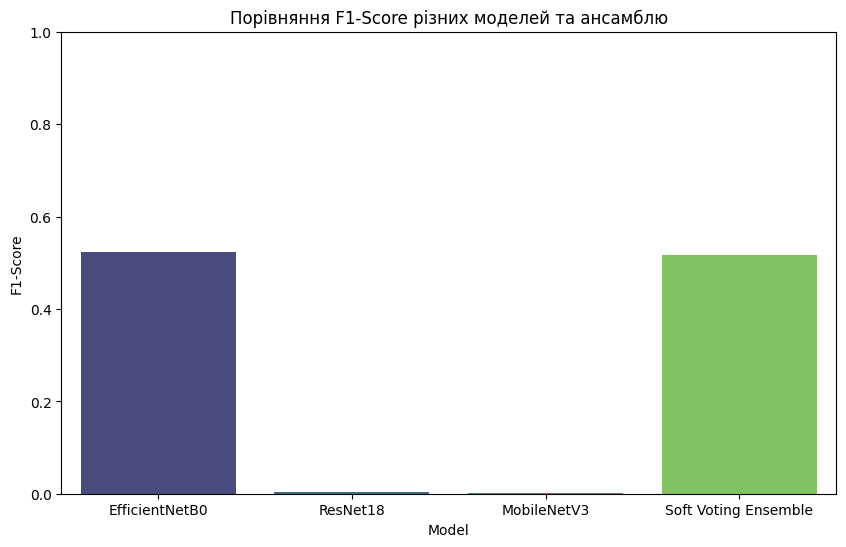

In [6]:
metrics_data = []

for name, preds in final_preds.items():
    acc = accuracy_score(all_labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, preds, average='macro', zero_division=0)
    
    metrics_data.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4)
    })

df_metrics = pd.DataFrame(metrics_data)
display(df_metrics)

# Зберігаємо як CSV для звіту
df_metrics.to_csv(results_dir / 'metrics_comparison.csv', index=False)

# Візуалізуємо F1-Score
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1-Score', data=df_metrics, palette='viridis')
plt.title('Порівняння F1-Score різних моделей та ансамблю')
plt.ylim(0, 1.0)
plt.savefig(results_dir / 'f1_score_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## 6. Матриця Помилок (Confusion Matrix)
Побудуємо матрицю плутанини для нашого Ансамблю. Оскільки класів 101, матриця буде дуже великою. Ми відмалюємо лише перші 10 класів для наглядності.


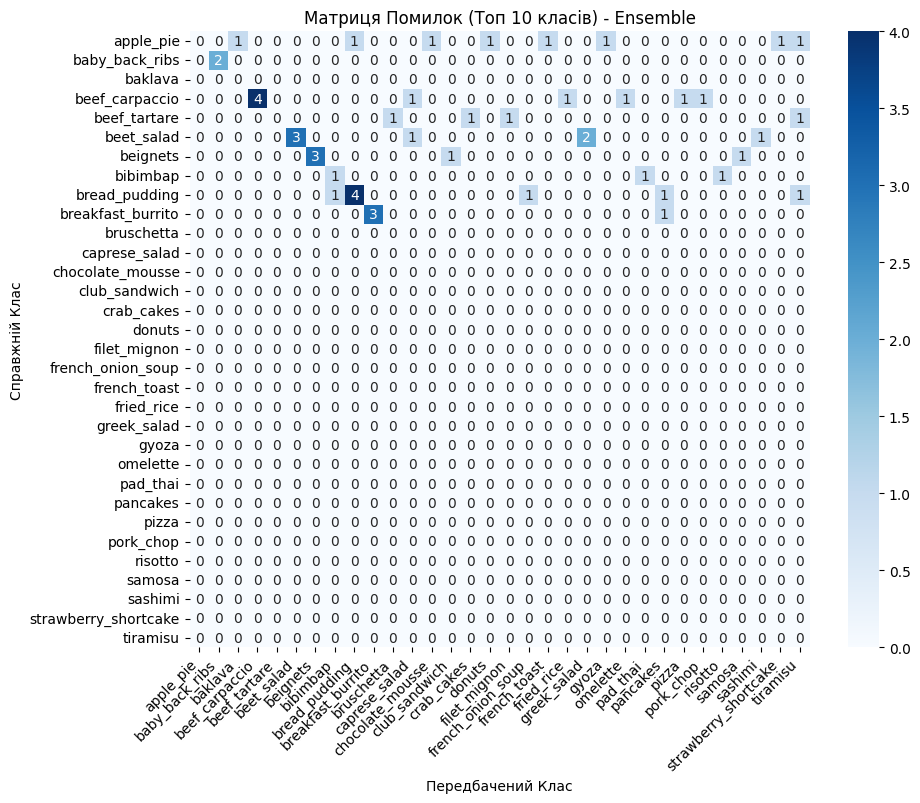

In [7]:
ensemble_preds = final_preds['Soft Voting Ensemble']

# Вибираємо тільки ті екземпляри, які належать до перших 10 класів
subset_indices = [i for i, label in enumerate(all_labels) if label < 10]
subset_labels = all_labels[subset_indices]
subset_preds = ensemble_preds[subset_indices]

# Якщо на сабсеті немає жодної картинки перших 10 класів, ми не зможемо побудувати матрицю
if len(subset_labels) > 0:
    # Залишаємо тільки ті класи, які реально зустрілися
    unique_classes = sorted(list(set(subset_labels) | set(subset_preds)))
    if max(unique_classes) >= 101: 
        unique_classes = [c for c in unique_classes if c < 101] # запобігання помилкам
        
    cm = confusion_matrix(subset_labels, subset_preds, labels=unique_classes)
    
    # Спроба отримати імена класів
    display_names = [classes[i] for i in unique_classes]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=display_names, yticklabels=display_names)
    plt.title('Матриця Помилок (Топ 10 класів) - Ensemble')
    plt.ylabel('Справжній Клас')
    plt.xlabel('Передбачений Клас')
    plt.xticks(rotation=45, ha='right')
    plt.savefig(results_dir / 'confusion_matrix_ensemble.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Недостатньо даних для побудови Confusion Matrix для перших 10 класів у поточному сабсеті.")
